# AST simulation using the GUI defaults

This notebook executes the same Dual-scale simulation case that is loaded by default in the GUI. The physical parameters, operating conditions, load profile, model 

selection, kinetic constants, time span, and ODE settings are read from `config/user_defaults.json`; the 1D integration is performed by the same `gui.runner.run` function 

used by the Simulation page. The 0D comparison uses the interface's `gui.runner.run_0d_companion` path with the same load and solver settings.

The configured AST contains 5000 cycles over 30000 s. Its full execution can require several hours. The optional `MFC_AST_VERIFY_SECONDS` environment variable is reserved 

for automated short-run verification and does not change the saved GUI defaults.

In [1]:
import os
import sys
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")

# Locate the project by its contents, so the notebook works from the project
# root and from subdirectories such as simulation/.
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "config" / "initialize.py").exists()
        and (path / "gui" / "runner.py").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the MFC2024 project root.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import user_defaults
from config.initialize import operating_inputs as BASE_OPERATING_INPUTS
from config.initialize import parameters as BASE_PARAMETERS
from gui.options import build_profile_func
from gui.runner import run as run_simulation, run_0d_companion

## Default simulation case

In [2]:
saved_defaults = user_defaults.load()

parameters = deepcopy(BASE_PARAMETERS)
parameters.update(saved_defaults["parameters"])
operating_inputs = deepcopy(BASE_OPERATING_INPUTS)
operating_inputs.update(saved_defaults["op_inputs"])
options = deepcopy(saved_defaults["options"])
kinetic_consts = deepcopy(saved_defaults["kinetic_consts"])

if options.get("profile_kind") != "Step":
    raise RuntimeError(
        "The GUI default profile must be 'Step' for this AST example; "
        f"found {options.get('profile_kind')!r}."
    )

profile_state = {
    "profile_kind": options["profile_kind"],
    "profile_cfg": options["profile_cfg"],
    "params": parameters,
}
current_density = build_profile_func(profile_state)

configured_t_start = float(options["t_start"])
configured_t_end = float(options["t_end"])
verify_duration = os.environ.get("MFC_AST_VERIFY_SECONDS")
simulation_t_end = configured_t_end
if verify_duration is not None:
    simulation_t_end = min(
        configured_t_end,
        configured_t_start + float(verify_duration),
    )
simulation_t_span = (configured_t_start, simulation_t_end)

profile_cfg = options["profile_cfg"]
cycle_period_s = float(profile_cfg["step_tend"] - profile_cfg["step_tstart"])
configured_cycles = (configured_t_end - configured_t_start) / cycle_period_s
executed_cycles = (simulation_t_end - configured_t_start) / cycle_period_s

print(f"Model: {options['model_variant']}")
print(f"Auxiliary system: {options['aux_system']}")
print(
    "Step profile: "
    f"{profile_cfg['i_low']:.0f} to {profile_cfg['i_high']:.0f} A/m^2, "
    f"period {cycle_period_s:g} s"
)
print(
    f"Configured span: {configured_t_start:g} to {configured_t_end:g} s "
    f"({configured_cycles:g} cycles)"
)
print(
    f"Executed span: {simulation_t_span[0]:g} to {simulation_t_span[1]:g} s "
    f"({executed_cycles:g} cycles)"
)
print(
    f"Solver: {options['method']}, max_step={options['max_step']:g} s, "
    "atol=1e-4 with Jacobian sparsity"
)

Model: Dual-scale
Auxiliary system: False
Step profile: 1000 to 14500 A/m^2, period 6 s
Configured span: 0 to 30000 s (5000 cycles)
Executed span: 0 to 30000 s (5000 cycles)
Solver: BDF, max_step=0.1 s, atol=1e-4 with Jacobian sparsity


## Dual-scale simulation

In [3]:
model, sol, status = run_simulation(
    params = parameters,
    op_inputs = operating_inputs,
    model_variant = options["model_variant"],
    profile_func = current_density,
    t_span = simulation_t_span,
    max_step = float(options["max_step"]),
    method = options["method"],
    aux_system = bool(options["aux_system"]),
    kinetic_consts = kinetic_consts )

if not status["success"] :
    raise RuntimeError(f"Simulation failed: {status['message']}")
if status.get("fallback_used") :
    raise RuntimeError(f"The requested {options['method']} solve required an unexpected LSODA fallback.")

print(f"Resolved model: {status['model_variant']}")
print(f"States: {status['n_states']}")
print(f"Accepted time points: {status['n_steps']}")
print(f"Runtime: {status['runtime_s']:.3f} s")
print(f"Solver message: {status['message']}")

Resolved model: Dual-scale (aux: off)
States: 218
Accepted time points: 477276
Runtime: 18117.712 s
Solver message: The solver successfully reached the end of the integration interval.


## 0D benchmark companion

In [4]:
benchmark_0d = run_0d_companion(
    params=parameters,
    op_inputs=operating_inputs,
    profile_func=current_density,
    t_span=simulation_t_span,
    max_step=float(options["max_step"]),
    method=options["method"],
)

benchmark_status = benchmark_0d["status"]
if not benchmark_status["success"]:
    raise RuntimeError(f"0D benchmark failed: {benchmark_status['message']}")

benchmark_variables = benchmark_0d["variables"]
benchmark_echem = benchmark_0d["echem_traj"]
benchmark_time_s = np.asarray(
    benchmark_echem.get("t", benchmark_variables.get("t", [])),
    dtype=float,
)
benchmark_Hmem_um = np.asarray(benchmark_variables.get("Hmem", []), dtype=float) * 1e6
benchmark_ecsa_ratio = np.asarray(benchmark_echem.get("S_N", []), dtype=float)

if not (
    benchmark_time_s.size
    and benchmark_Hmem_um.size
    and benchmark_ecsa_ratio.size
):
    raise RuntimeError("0D benchmark did not recover Hmem and S_N trajectories.")

benchmark_cycles = (benchmark_time_s - configured_t_start) / cycle_period_s

print("Resolved model: 0D benchmark")
print(f"Accepted time points: {benchmark_status['n_steps']}")
print(f"Runtime: {benchmark_status['runtime_s']:.3f} s")
print(f"Solver message: {benchmark_status['message']}")

Resolved model: 0D benchmark
Accepted time points: 676895
Runtime: 5021.459 s
Solver message: The solver successfully reached the end of the integration interval.


## Cell response over the first three cycles

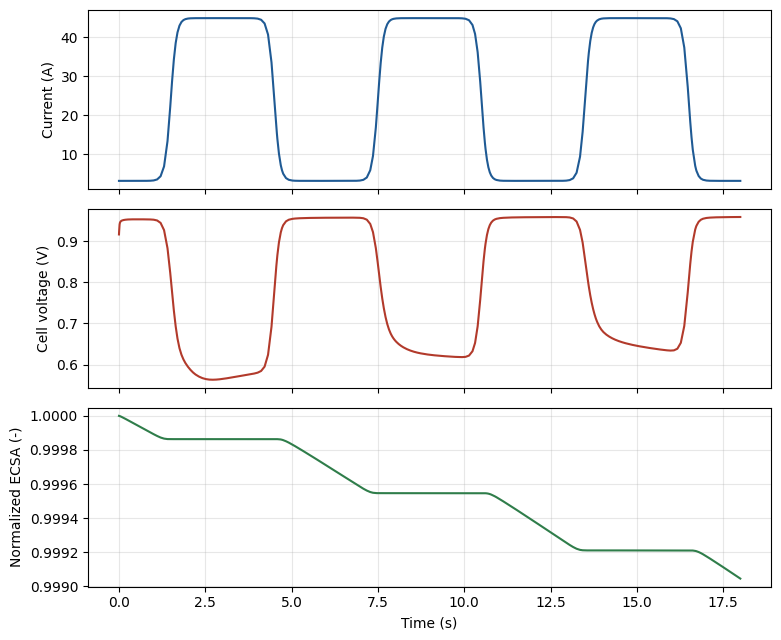

In [5]:
time_s = np.asarray(model.variables["t"], dtype=float)
current_A = np.asarray([current_density(t) for t in time_s]) * parameters["Aact"]
voltage_V = np.asarray(model.echem_traj["Ucell"], dtype=float)
ecsa_ratio = np.asarray(model.echem_traj["S_N"], dtype=float)

response_end = min(time_s[-1], configured_t_start + 3.0 * cycle_period_s)
response_mask = time_s <= response_end

fig, axes = plt.subplots(3, 1, figsize=(8.0, 6.5), sharex=True)
axes[0].plot(time_s[response_mask], current_A[response_mask], color="#1f5a94")
axes[0].set_ylabel("Current (A)")
axes[1].plot(time_s[response_mask], voltage_V[response_mask], color="#b23a2b")
axes[1].set_ylabel("Cell voltage (V)")
axes[2].plot(time_s[response_mask], ecsa_ratio[response_mask], color="#2f7d4a")
axes[2].set_ylabel("Normalized ECSA (-)")
axes[2].set_xlabel("Time (s)")
for axis in axes:
    axis.grid(alpha=0.3)
fig.tight_layout()

## Internal degradation-state evolution

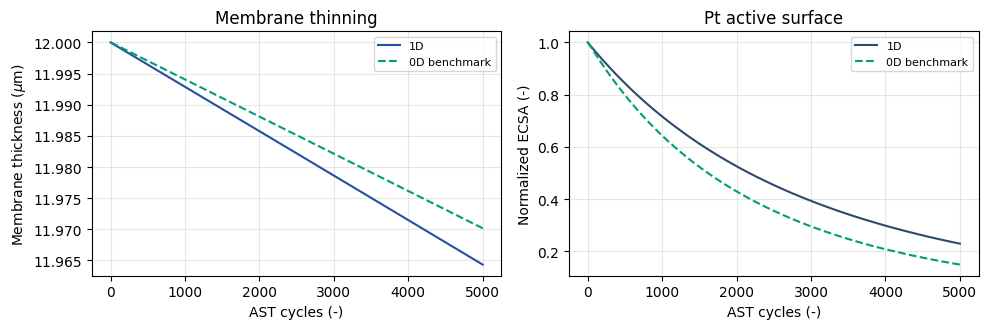

In [6]:
cycles = (time_s - configured_t_start) / cycle_period_s
membrane_thickness_um = np.asarray(
    model.variables["delta_mem"], dtype=float
) * 1e6

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4))

n_1d_mem = min(cycles.size, membrane_thickness_um.size)
n_0d_mem = min(benchmark_cycles.size, benchmark_Hmem_um.size)
axes[0].plot(
    cycles[:n_1d_mem],
    membrane_thickness_um[:n_1d_mem],
    color="#264f9e",
    linewidth=1.5,
    label="1D",
)
axes[0].plot(
    benchmark_cycles[:n_0d_mem],
    benchmark_Hmem_um[:n_0d_mem],
    color="#009E73",
    linestyle="--",
    linewidth=1.5,
    label="0D benchmark",
)
axes[0].set_title("Membrane thinning")
axes[0].set_xlabel("AST cycles (-)")
axes[0].set_ylabel(r"Membrane thickness ($\mu$m)")
axes[0].grid(alpha=0.3)
axes[0].ticklabel_format(axis="y", style="plain", useOffset=False)
axes[0].legend(fontsize=8, loc="best")

n_1d_ecsa = min(cycles.size, ecsa_ratio.size)
n_0d_ecsa = min(benchmark_cycles.size, benchmark_ecsa_ratio.size)
axes[1].plot(
    cycles[:n_1d_ecsa],
    ecsa_ratio[:n_1d_ecsa],
    color="#2f496e",
    linewidth=1.5,
    label="1D",
)
axes[1].plot(
    benchmark_cycles[:n_0d_ecsa],
    benchmark_ecsa_ratio[:n_0d_ecsa],
    color="#009E73",
    linestyle="--",
    linewidth=1.5,
    label="0D benchmark",
)
axes[1].set_title("Pt active surface")
axes[1].set_xlabel("AST cycles (-)")
axes[1].set_ylabel("Normalized ECSA (-)")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8, loc="best")

assert len(axes[0].lines) == 2
assert len(axes[1].lines) == 2
fig.tight_layout()

In [7]:
result_summary = {
    "configured_duration_s": configured_t_end - configured_t_start,
    "executed_duration_s": simulation_t_end - configured_t_start,
    "configured_cycles": configured_cycles,
    "executed_cycles": executed_cycles,
    "final_1D_cell_voltage_V": float(voltage_V[-1]),
    "final_1D_membrane_thickness_um": float(membrane_thickness_um[-1]),
    "final_0D_membrane_thickness_um": float(benchmark_Hmem_um[-1]),
    "final_1D_normalized_ECSA": float(ecsa_ratio[-1]),
    "final_0D_normalized_ECSA": float(benchmark_ecsa_ratio[-1]),
    "runtime_1D_s": float(status["runtime_s"]),
    "runtime_0D_s": float(benchmark_status["runtime_s"]),
}
result_summary

{'configured_duration_s': 30000.0,
 'executed_duration_s': 30000.0,
 'configured_cycles': 5000.0,
 'executed_cycles': 5000.0,
 'final_1D_cell_voltage_V': 0.9598545168912358,
 'final_1D_membrane_thickness_um': 11.96433356928072,
 'final_0D_membrane_thickness_um': 11.970165936268863,
 'final_1D_normalized_ECSA': 0.22964485830907871,
 'final_0D_normalized_ECSA': 0.14947084887335116,
 'runtime_1D_s': 18117.711731,
 'runtime_0D_s': 5021.4590155000005}